# Eksperimen YOLO Modern untuk Deteksi Objek Kecil Berkelompok pada Global Wheat Detection

**Platform:** Kaggle Notebook  
**Model modern:** YOLOv8n (Ultralytics)  
**Dataset:** Global Wheat Detection  
**Paper utama:** Redmon et al. (2016), *You Only Look Once: Unified, Real-Time Object Detection*, CVPR.

## Tujuan eksperimen
1. Memahami prinsip dasar YOLOv1 melalui implementasi target encoding dan fungsi loss.
2. Menguji apakah keterbatasan YOLO pada objek kecil yang berkelompok masih muncul pada YOLO modern.
3. Membandingkan **baseline resolusi 640×640** dengan **intervensi resolusi 1024×1024** menggunakan model dan pengaturan pelatihan yang sama.
4. Mengevaluasi **mAP@0.5**, **mAP@0.5:0.95**, serta AP berdasarkan ukuran objek **small / medium / large**.
5. Menampilkan contoh *failure cases* untuk mendukung analisis kritis.

### Pertanyaan riset
**Apakah peningkatan resolusi input dari 640×640 menjadi 1024×1024 meningkatkan kinerja YOLOv8n, terutama pada objek gandum berukuran kecil dan berkelompok?**

> Sel-sel data import Kaggle, URL dataset, serta kode yang sebelumnya sudah ada tetap dipertahankan. Penambahan di notebook ini berfungsi melengkapi alur eksperimen agar menyerupai struktur notebook tutorial dan memenuhi kebutuhan tugas.


## 1. Setup lingkungan

Bagian ini menginstal library yang diperlukan dan menyiapkan environment. Kode instalasi Kaggle dan Ultralytics dari notebook awal tetap dipertahankan.


In [1]:
# Install Kaggle
!pip install kaggle --quiet

# Install UltraLyrics
!pip -q install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 10.5 MB/s eta 0:00:00


In [2]:
import os, glob, zipfile, socket, urllib.request, time, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from PIL import Image
from ultralytics import YOLO
from tqdm.notebook import tqdm

socket.setdefaulttimeout(120)
plt.rcParams['figure.dpi'] = 100
SEED = 42
DEVICE = 0 if torch.cuda.is_available() else 'cpu'
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'tidak ada (pelatihan akan lambat)')

# Menampilkan versi library utama agar eksperimen lebih mudah direproduksi
import ultralytics
print("Versi PyTorch     :", torch.__version__)
print("Versi Ultralytics:", ultralytics.__version__)
print("Device            :", DEVICE)


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
GPU: Tesla T4
Versi PyTorch     : 2.11.0+cu130
Versi Ultralytics: 8.4.173
Device            : 0


In [4]:
# Menetapkan seed secara lengkap agar pembagian data dan proses pelatihan lebih konsisten
import random

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Meminta algoritme deterministik ketika memungkinkan
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception:
    pass

# Folder khusus untuk tabel/gambar yang akan digunakan pada laporan
REPORT_DIR = "/content/Report"
os.makedirs(REPORT_DIR, exist_ok=True)

print("Seed eksperimen:", SEED)
print("Folder output laporan:", REPORT_DIR)


Seed eksperimen: 42
Folder output laporan: /content/Report


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Unduh / akses dataset Global Wheat Detection

Dataset diperoleh dari Kaggle. Sel URL dan proses download dari notebook awal **tidak dihapus**.


In [6]:
!pip install legacy-cgi
!pip install opendatasets --upgrade -q
import opendatasets as od

dataset_url = "https://www.kaggle.com/competitions/global-wheat-detection/data"
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: bhimafairulrifqi
Your Kaggle Key: ··········


100%|██████████| 607M/607M [00:17<00:00, 35.7MB/s]



Extracting archive ./global-wheat-detection/global-wheat-detection.zip to ./global-wheat-detection


## 3. Membaca anotasi Global Wheat Detection

Anotasi asli Global Wheat Detection menggunakan format `[x, y, width, height]`. Fungsi berikut mengubahnya menjadi `[xmin, ymin, xmax, ymax]` agar mudah digunakan pada visualisasi, perhitungan IoU, dan demonstrasi YOLOv1.


In [7]:
import ast
import glob
import os
import numpy as np
import pandas as pd
from PIL import Image


def load_global_wheat(root):
    csv_path = os.path.join(root, "train.csv")
    df = pd.read_csv(csv_path)

    # Group annotations by image_id for quick retrieval
    grouped = df.groupby("image_id")

    records = []
    # Iterate over image files in the 'train' folder (.jpg format)
    for p in sorted(glob.glob(os.path.join(root, "train", "*.jpg"))):
        name = os.path.splitext(os.path.basename(p))[0]

        boxes = []
        if name in grouped.groups:
            img_df = grouped.get_group(name)
            for bbox_str in img_df["bbox"]:
                # Parse '[x, y, w, h]' string to floats
                x, y, w, h = ast.literal_eval(bbox_str)
                # Convert [x, y, w, h] to Pascal VOC [xmin, ymin, xmax, ymax]
                boxes.append([x, y, x + w, y + h])

            W = int(img_df["width"].iloc[0])
            H = int(img_df["height"].iloc[0])
        else:
            # Fallback for images without bounding boxes
            W, H = Image.open(p).size

        records.append(
            {
                "name": name,
                "path": p,
                "W": W,
                "H": H,
                "boxes": np.array(boxes, dtype=float).reshape(-1, 4),
            }
        )

    return records

In [8]:
# Set the root directory of the extracted dataset
wheat_dataset_root = '/content/global-wheat-detection'

# Pass the root directory to your function
records = load_global_wheat(wheat_dataset_root)
perm = np.random.default_rng(SEED).permutation(len(records))
test_recs = [records[i] for i in perm[:50]]
train_recs = [records[i] for i in perm[50:]]
gts = {r['name']: r['boxes'] for r in test_recs}
print(f'latih {len(train_recs)} | uji {len(test_recs)} | GT uji {sum(len(g) for g in gts.values())}')

latih 3372 | uji 50 | GT uji 2204


In [9]:
def draw_boxes(ax, boxes, color, lw=2, scores=None):
    for k, (x1, y1, x2, y2) in enumerate(boxes):
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, ec=color, lw=lw))
        if scores is not None:
            ax.text(x1, y1 - 2, f'{scores[k]:.2f}', color=color, fontsize=8)

In [10]:
# Eksplorasi singkat dataset agar jumlah citra, objek, dan karakteristik anotasi terdokumentasi
csv_eda_path = os.path.join(wheat_dataset_root, "train.csv")
df_eda = pd.read_csv(csv_eda_path)

# Mengubah string bbox menjadi angka untuk menghitung lebar, tinggi, dan luas objek
bbox_values = df_eda["bbox"].apply(ast.literal_eval)
df_eda["bbox_w"] = bbox_values.apply(lambda b: float(b[2]))
df_eda["bbox_h"] = bbox_values.apply(lambda b: float(b[3]))
df_eda["bbox_area"] = df_eda["bbox_w"] * df_eda["bbox_h"]

print("Jumlah citra unik :", df_eda["image_id"].nunique())
print("Jumlah anotasi    :", len(df_eda))
print("Ukuran citra unik :", sorted(df_eda[["width", "height"]].drop_duplicates().itertuples(index=False, name=None))[:10])
print("Rata-rata objek/citra:", round(len(df_eda) / df_eda["image_id"].nunique(), 2))

display(df_eda[["image_id", "width", "height", "bbox", "bbox_area"]].head())


Jumlah citra unik : 3373
Jumlah anotasi    : 147793
Ukuran citra unik : [(1024, 1024)]
Rata-rata objek/citra: 43.82


,image_id,width,height,bbox,bbox_area
0,b6ab77fd7,1024,1024,"[834.0, 222.0, 56.0, 36.0]",2016.0
1,b6ab77fd7,1024,1024,"[226.0, 548.0, 130.0, 58.0]",7540.0
2,b6ab77fd7,1024,1024,"[377.0, 504.0, 74.0, 160.0]",11840.0
3,b6ab77fd7,1024,1024,"[834.0, 95.0, 109.0, 107.0]",11663.0
4,b6ab77fd7,1024,1024,"[26.0, 144.0, 124.0, 117.0]",14508.0


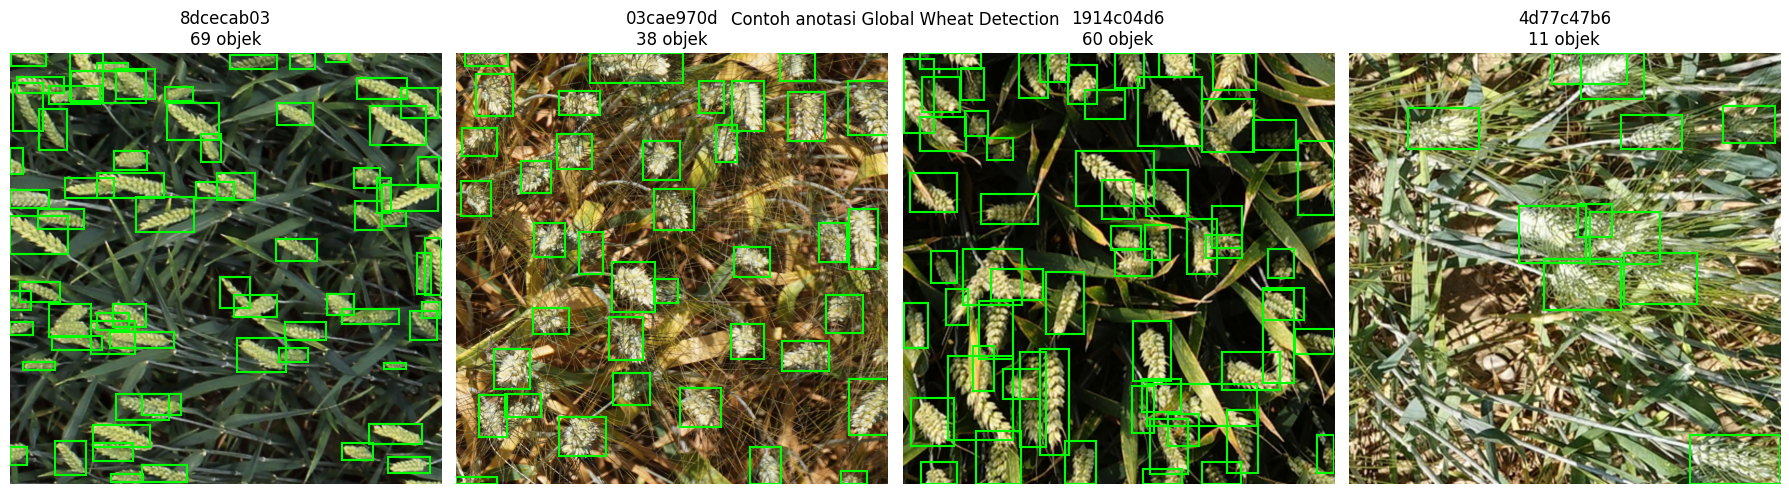

In [12]:
# Visualisasi beberapa contoh citra beserta ground-truth bounding box
sample_recs = train_recs[:4]
fig, axs = plt.subplots(1, len(sample_recs), figsize=(18, 5))

for ax, rec in zip(axs, sample_recs):
    ax.imshow(Image.open(rec["path"]))
    draw_boxes(ax, rec["boxes"], "lime", lw=1.5)
    ax.set_title(f"{rec['name']}\n{len(rec['boxes'])} objek")
    ax.axis("off")

plt.suptitle("Contoh anotasi Global Wheat Detection")
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "contoh_ground_truth.png"), bbox_inches="tight")
plt.show()


## 4. Implementasi konsep YOLOv1 dari paper Redmon et al. (2016)

YOLOv1 membagi citra menjadi grid $S\times S$. Sel yang memuat **titik pusat objek** bertanggung jawab terhadap prediksi objek tersebut. Untuk demonstrasi satu kelas (`wheat`), target sederhana berisi posisi box, confidence, dan kelas.

Bagian ini dipertahankan dari notebook awal karena penting untuk menunjukkan hubungan implementasi dengan paper utama.


In [13]:
def encode_yolov1_target(boxes, W, H, S=7, C=1, classes=None):
  T = np.zeros((S, S, 5 + C), np.float32)
  classes = np.zeros(len(boxes), int) if classes is None else classes
  for (x1, y1, x2, y2), c in zip(boxes, classes):
    cx, cy = (x1 + x2) / 2 / W, (y1 + y2) / 2 / H
    bw, bh = (x2 - x1) / W, (y2 - y1) / H
    col, row = min(int(cx * S), S - 1), min(int(cy * S), S - 1)
    if T[row, col, 4] == 1:
        continue
    T[row, col, :5] = [cx * S - col, cy * S - row, bw, bh, 1.0]
    T[row, col, 5 + c] = 1.0
  return T

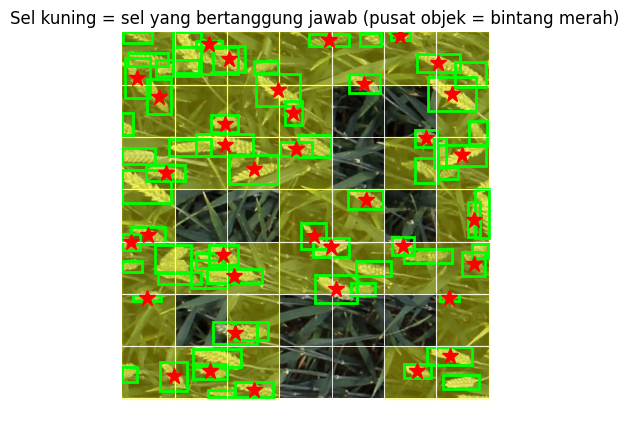

Bentuk target: (7, 7, 6) | jumlah sel berisi objek: 37


In [14]:
r = train_recs[0]
S = 7
T = encode_yolov1_target(r['boxes'], r['W'], r['H'], S=S)
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(Image.open(r['path']))
for k in range(1, S):
  ax.axhline(k * r['H'] / S, color='w', lw=.6); ax.axvline(k * r['W'] / S, color='w', lw=.6)
for row, col in zip(*np.where(T[..., 4] == 1)):
  ax.add_patch(patches.Rectangle((col * r['W'] / S, row * r['H'] / S), r['W'] / S, r['H'] / S, color='yellow', alpha=.35))
  x, y = (col + T[row, col, 0]) * r['W'] / S, (row + T[row, col, 1]) * r['H'] / S
  ax.plot(x, y, 'r*', ms=12)
draw_boxes(ax, r['boxes'], 'lime')
ax.set_title('Sel kuning = sel yang bertanggung jawab (pusat objek = bintang merah)'); ax.axis('off'); plt.show()
print('Bentuk target:', T.shape, '| jumlah sel berisi objek:', int(T[..., 4].sum()))

### Fungsi loss YOLOv1

Implementasi berikut memisahkan komponen koordinat pusat, ukuran box, confidence pada sel berobjek, confidence pada sel kosong, dan klasifikasi. Konstanta $\lambda_{coord}=5$ serta $\lambda_{noobj}=0.5$ mengikuti formulasi YOLOv1.


In [15]:
def yolov1_loss(pred, target, l_coord=5.0, l_noobj=0.5):
    obj = target[..., 4] == 1
    noobj = ~obj
    xy = np.sum((target[obj, 0:2] - pred[obj, 0:2]) ** 2)
    wh = np.sum((np.sqrt(target[obj, 2:4]) - np.sqrt(pred[obj, 2:4])) ** 2)
    conf_obj = np.sum((target[obj, 4] - pred[obj, 4]) ** 2)
    conf_noobj = np.sum((target[noobj, 4] - pred[noobj, 4]) ** 2)
    cls = np.sum((target[obj, 5:] - pred[obj, 5:]) ** 2)
    return {'coord_xy': l_coord * xy, 'coord_wh': l_coord * wh, 'conf_obj': conf_obj,
            'conf_noobj': l_noobj * conf_noobj, 'class': cls,
            'total': l_coord * (xy + wh) + conf_obj + l_noobj * conf_noobj + cls}

In [16]:
rng = np.random.default_rng(SEED)
pred_random = rng.uniform(0, 1, T.shape).astype(np.float32)
pred_good = T.copy(); pred_good[..., :4] += rng.normal(0, 0.02, T[..., :4].shape); pred_good = np.clip(pred_good, 0, 1)
print('Prediksi acak  :', {k: round(float(v), 3) for k, v in yolov1_loss(pred_random, T).items()})
print('Prediksi dekat :', {k: round(float(v), 3) for k, v in yolov1_loss(pred_good, T).items()})

Prediksi acak  : {'coord_xy': 81.75, 'coord_wh': 76.167, 'conf_obj': 13.784, 'conf_noobj': 1.946, 'class': 12.212, 'total': 185.86}
Prediksi dekat : {'coord_xy': 0.107, 'coord_wh': 0.791, 'conf_obj': 0.0, 'conf_noobj': 0.0, 'class': 0.0, 'total': 0.898}


### Catatan mengenai keterbatasan objek kecil berkelompok

Pada representasi grid YOLOv1, beberapa objek yang pusatnya jatuh pada sel yang sama dapat menimbulkan konflik representasi. Pada contoh Global Wheat, satu citra dapat memiliki puluhan kepala gandum yang saling berdekatan. Inilah kondisi yang relevan untuk menguji apakah masalah tersebut masih terlihat pada YOLO modern.


## 5. Persiapan eksperimen utama YOLO modern

Notebook awal sudah memiliki seed tambahan, instalasi `pycocotools`, serta `sahi`. Sel tersebut tetap dipertahankan.


In [17]:
import os
import random
import numpy as np
import torch

# Setting Random Seed untuk Reproduksibilitas Penugasan
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"CUDA Available: {torch.cuda.is_available()}")
!pip install -q ultralytics pycocotools sahi

CUDA Available: True
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 11.8 MB/s eta 0:00:00


## 6. Konversi anotasi ke format YOLO

Format label Ultralytics adalah satu file `.txt` untuk setiap citra dengan format:

```text
<class_id> <x_center> <y_center> <width> <height>
```

Semua koordinat dinormalisasi ke rentang 0–1. Kode konversi awal dan penyesuaian path yang sudah ada **tetap dipertahankan** di bawah ini.


In [19]:
import ast
import glob
import shutil
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split

# 1. Unduh Dataset via Kaggle API / Direct Link
# Pastikan file train.csv dan folder train/ ada di direktori kerja
os.makedirs("dataset/images/train", exist_ok=True)
os.makedirs("dataset/images/val", exist_ok=True)
os.makedirs("dataset/labels/train", exist_ok=True)
os.makedirs("dataset/labels/val", exist_ok=True)

# Simulasi / Eksekusi Konversi CSV ke Format Label YOLO TXT
df = pd.read_csv("/content/global-wheat-detection/train.csv")
grouped = df.groupby("image_id")
image_ids = list(grouped.groups.keys())

train_ids, val_ids = train_test_split(
    image_ids, test_size=0.2, random_state=SEED
)


def process_dataset_split(img_ids, split_name):
    for img_id in img_ids:
        group = grouped.get_group(img_id)
        img_path = os.path.join("train", f"{img_id}.jpg")
        if not os.path.exists(img_path):
            continue

        # Pindahkan Gambar
        dest_img_path = os.path.join(
            f"dataset/images/{split_name}", f"{img_id}.jpg"
        )
        shutil.copy(img_path, dest_img_path)

        # Buat File Label TXT
        label_path = os.path.join(
            f"dataset/labels/{split_name}", f"{img_id}.txt"
        )
        with open(label_path, "w") as f:
            for _, row in group.iterrows():
                bbox = ast.literal_eval(row["bbox"])
                x, y, w, h = bbox[0], bbox[1], bbox[2], bbox[3]
                img_w, img_h = row["width"], row["height"]

                # Normalisasi ke format YOLO (class_id x_center y_center width height)
                x_center = (x + w / 2) / img_w
                y_center = (y + h / 2) / img_h
                w_norm = w / img_w
                h_norm = h / img_h

                f.write(
                    f"0 {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}\n"
                )


process_dataset_split(train_ids, "train")
process_dataset_split(val_ids, "val")

# Buat Config YAML
yaml_content = """
path: ./dataset
train: images/train
val: images/val

names:
  0: wheat
"""
with open("wheat.yaml", "w") as f:
    f.write(yaml_content)

In [20]:
import ast
import glob
import os
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Definisikan path berdasarkan struktur folder Anda
DATASET_ROOT = "global-wheat-detection"
CSV_PATH = os.path.join(DATASET_ROOT, "train.csv")
TRAIN_IMAGES_DIR = os.path.join(DATASET_ROOT, "train")

# Folder tujuan khusus untuk format pelatihan YOLO
OUTPUT_DIR = "dataset"
os.makedirs(f"{OUTPUT_DIR}/images/train", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/images/val", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/labels/train", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/labels/val", exist_ok=True)

# 2. Baca train.csv dan kelompokkan berdasarkan image_id
df = pd.read_csv(CSV_PATH)
grouped = df.groupby("image_id")
image_ids = list(grouped.groups.keys())

# Pembagian data 80% train dan 20% validation
train_ids, val_ids = train_test_split(
    image_ids, test_size=0.2, random_state=SEED
)


def process_dataset_split(img_ids, split_name):
    for img_id in img_ids:
        # Lokasi asal gambar di folder global-wheat-detection/train/
        img_path = os.path.join(TRAIN_IMAGES_DIR, f"{img_id}.jpg")
        if not os.path.exists(img_path):
            continue

        # Salin gambar ke folder format YOLO
        dest_img_path = os.path.join(
            OUTPUT_DIR, "images", split_name, f"{img_id}.jpg"
        )
        shutil.copy(img_path, dest_img_path)

        # Buat file label .txt format YOLO (class x_center y_center width height)
        label_path = os.path.join(
            OUTPUT_DIR, "labels", split_name, f"{img_id}.txt"
        )
        if img_id in grouped.groups:
            group = grouped.get_group(img_id)
            with open(label_path, "w") as f:
                for _, row in group.iterrows():
                    bbox = ast.literal_eval(row["bbox"])
                    x, y, w, h = bbox[0], bbox[1], bbox[2], bbox[3]
                    img_w, img_h = row["width"], row["height"]

                    # Normalisasi koordinat bounding box (0 - 1)
                    x_center = (x + w / 2) / img_w
                    y_center = (y + h / 2) / img_h
                    w_norm = w / img_w
                    h_norm = h / img_h

                    f.write(
                        f"0 {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}\n"
                    )


print("Memproses data train...")
process_dataset_split(train_ids, "train")

print("Memproses data validation...")
process_dataset_split(val_ids, "val")

# 3. Buat file konfigurasi wheat.yaml
yaml_content = f"""
path: ./{OUTPUT_DIR}
train: images/train
val: images/val

names:
  0: wheat
"""
with open("wheat.yaml", "w") as f:
    f.write(yaml_content)

print("Proses penyesuaian path dan konversi ke format YOLO selesai!")

Memproses data train...
Memproses data validation...
Proses penyesuaian path dan konversi ke format YOLO selesai!


In [22]:
# Verifikasi bahwa hasil konversi benar-benar tersedia sebelum pelatihan
train_image_files = sorted(glob.glob(os.path.join(OUTPUT_DIR, "images", "train", "*.jpg")))
val_image_files = sorted(glob.glob(os.path.join(OUTPUT_DIR, "images", "val", "*.jpg")))
train_label_files = sorted(glob.glob(os.path.join(OUTPUT_DIR, "labels", "train", "*.txt")))
val_label_files = sorted(glob.glob(os.path.join(OUTPUT_DIR, "labels", "val", "*.txt")))

print("Train images :", len(train_image_files))
print("Train labels :", len(train_label_files))
print("Val images   :", len(val_image_files))
print("Val labels   :", len(val_label_files))

assert len(train_image_files) > 0, "Folder train kosong. Periksa path dataset."
assert len(val_image_files) > 0, "Folder validation kosong. Periksa path dataset."
assert len(train_image_files) == len(train_label_files), "Jumlah image dan label train tidak sama."
assert len(val_image_files) == len(val_label_files), "Jumlah image dan label val tidak sama."

print("Isi wheat.yaml:")
print(open("wheat.yaml", "r").read())

print("Contoh label YOLO:")
with open(train_label_files[0], "r") as f:
    print("".join(f.readlines()[:5]))


Train images : 2698
Train labels : 2698
Val images   : 675
Val labels   : 675
Isi wheat.yaml:

path: ./dataset
train: images/train
val: images/val

names:
  0: wheat

Contoh label YOLO:
0 0.803711 0.896973 0.113281 0.077148
0 0.156738 0.573242 0.149414 0.093750
0 0.881836 0.799805 0.093750 0.074219
0 0.844238 0.955078 0.129883 0.085938
0 0.393066 0.490723 0.141602 0.209961



## 7. Distribusi ukuran objek: small, medium, large

Untuk evaluasi berbasis ukuran objek digunakan batas area standar COCO pada koordinat citra asli:

- **Small:** area < $32^2$ piksel
- **Medium:** $32^2 \leq$ area < $96^2$ piksel
- **Large:** area $\geq 96^2$ piksel

Distribusi ini membantu menjelaskan apakah dataset memang didominasi objek kecil/menengah dan menjadi dasar pembacaan AP per ukuran.


,Jumlah objek,Persentase (%)
size_category,,
small,1287,0.87
medium,117135,79.26
large,29371,19.87


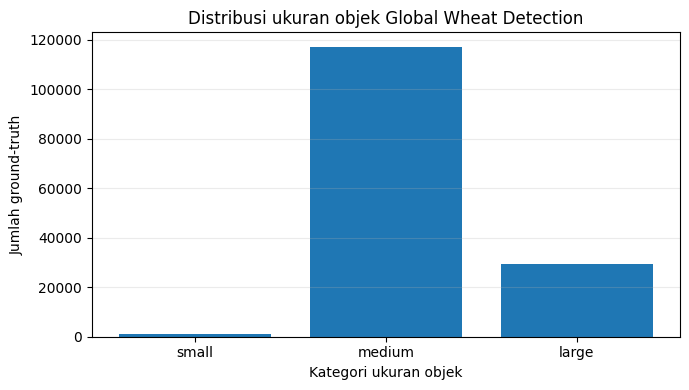

In [23]:
# Mengelompokkan setiap ground-truth box berdasarkan area piksel asli
def kategori_ukuran_objek(area):
    if area < 32 ** 2:
        return "small"
    elif area < 96 ** 2:
        return "medium"
    return "large"

size_df = df_eda.copy()
size_df["size_category"] = size_df["bbox_area"].apply(kategori_ukuran_objek)

size_counts = (
    size_df["size_category"]
    .value_counts()
    .reindex(["small", "medium", "large"], fill_value=0)
)
size_percent = (size_counts / size_counts.sum() * 100).round(2)

size_table = pd.DataFrame({
    "Jumlah objek": size_counts,
    "Persentase (%)": size_percent,
})

display(size_table)
size_table.to_csv(os.path.join(REPORT_DIR, "distribusi_ukuran_objek.csv"))

plt.figure(figsize=(7, 4))
plt.bar(size_counts.index, size_counts.values)
plt.xlabel("Kategori ukuran objek")
plt.ylabel("Jumlah ground-truth")
plt.title("Distribusi ukuran objek Global Wheat Detection")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "distribusi_ukuran_objek.png"), bbox_inches="tight")
plt.show()


## 8. Desain eksperimen YOLO modern

Model yang digunakan adalah **YOLOv8n** dengan bobot pralatih COCO sebagai inisialisasi transfer learning. Karena COCO tidak memiliki kelas `wheat`, bobot COCO tidak diperlakukan sebagai baseline zero-shot untuk kelas gandum; bobot tersebut hanya menjadi titik awal pelatihan.

Dua eksperimen dibuat seadil mungkin:

| Eksperimen | Model | Resolusi input | Epoch | Batch | Seed |
|---|---|---:|---:|---:|---:|
| Baseline | YOLOv8n | 640 | 15 | 16 | 42 |
| Intervensi | YOLOv8n | 1024 | 15 | 16 | 42 |

Variabel utama yang diubah adalah **resolusi input**. Intervensi 1024 dipilih karena citra Global Wheat Detection asli berukuran 1024×1024 sehingga detail objek kecil dipertahankan lebih banyak daripada ketika citra dikecilkan menjadi 640×640.


In [24]:
from ultralytics import YOLO

# Baseline Model: YOLOv8 Nano pada 640x640
model_baseline = YOLO("yolov8n.pt")
results_baseline = model_baseline.train(
    data="wheat.yaml",
    epochs=15,
    imgsz=640,
    batch=16,
    seed=SEED,
    project="wheat_exp",
    name="baseline_640",
    deterministic=True,
    device=DEVICE,
    workers=2,
    plots=True,
    exist_ok=True,
)

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=wheat.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_640, nbs=64, nms=None, opset=None, optimize=False, optimizer=auto, ove

Folder baseline : /content/runs/detect/wheat_exp/baseline_640
Checkpoint      : /content/runs/detect/wheat_exp/baseline_640/weights/best.pt


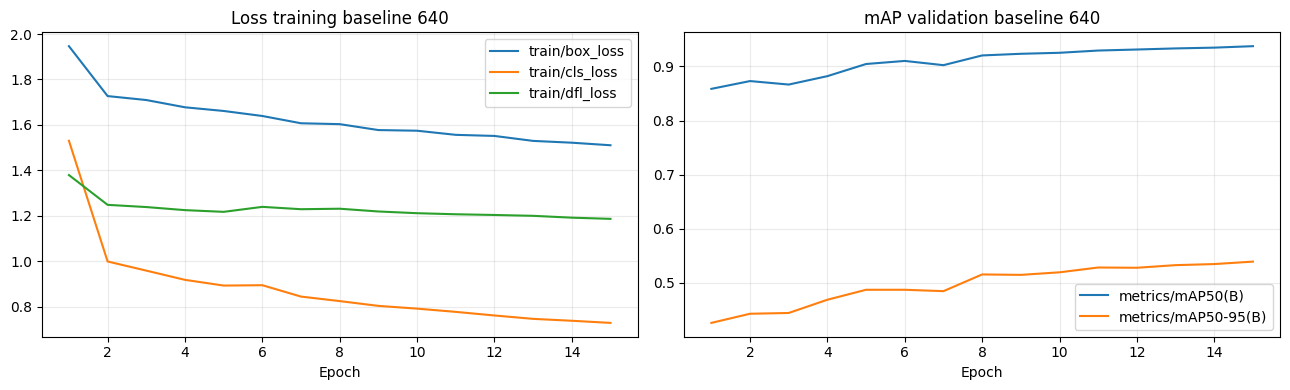

In [25]:
# Menyimpan lokasi hasil baseline secara dinamis agar tidak bergantung pada nama folder manual
baseline_dir = str(results_baseline.save_dir)
baseline_best = os.path.join(baseline_dir, "weights", "best.pt")
baseline_last = os.path.join(baseline_dir, "weights", "last.pt")

if not os.path.exists(baseline_best):
    baseline_best = baseline_last

print("Folder baseline :", baseline_dir)
print("Checkpoint      :", baseline_best)

# Menampilkan kurva loss dan mAP baseline yang dibuat oleh Ultralytics
baseline_csv = os.path.join(baseline_dir, "results.csv")
if os.path.exists(baseline_csv):
    base_hist = pd.read_csv(baseline_csv)
    base_hist.columns = [c.strip() for c in base_hist.columns]

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    for c in ["train/box_loss", "train/cls_loss", "train/dfl_loss"]:
        if c in base_hist.columns:
            ax[0].plot(base_hist["epoch"], base_hist[c], label=c)
    ax[0].set_title("Loss training baseline 640")
    ax[0].set_xlabel("Epoch")
    ax[0].legend()
    ax[0].grid(alpha=0.25)

    for c in ["metrics/mAP50(B)", "metrics/mAP50-95(B)"]:
        if c in base_hist.columns:
            ax[1].plot(base_hist["epoch"], base_hist[c], label=c)
    ax[1].set_title("mAP validation baseline 640")
    ax[1].set_xlabel("Epoch")
    ax[1].legend()
    ax[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig(os.path.join(REPORT_DIR, "training_baseline_640.png"), bbox_inches="tight")
    plt.show()


## 9. Intervensi: resolusi input lebih tinggi (1024×1024)

Eksperimen kedua menggunakan model, epoch, batch, seed, dan dataset yang sama. Perbedaan utama hanya `imgsz=1024`. Dengan demikian pengaruh perubahan resolusi dapat dibandingkan dengan baseline 640 secara lebih adil.


In [26]:
from ultralytics import YOLO

# Intervensi Model: YOLOv8 Nano pada resolusi 1024x1024
model_highres = YOLO("yolov8n.pt")
results_highres = model_highres.train(
    data="wheat.yaml",
    epochs=15,
    imgsz=1024,
    batch=16,
    seed=SEED,
    project="wheat_exp",
    name="intervention_1024",
    deterministic=True,
    device=DEVICE,
    workers=2,
    plots=True,
    exist_ok=True,
)

# Lokasi checkpoint terbaik intervensi
highres_dir = str(results_highres.save_dir)
highres_best = os.path.join(highres_dir, "weights", "best.pt")
highres_last = os.path.join(highres_dir, "weights", "last.pt")
if not os.path.exists(highres_best):
    highres_best = highres_last

print("Folder intervensi:", highres_dir)
print("Checkpoint       :", highres_best)


Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=wheat.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=intervention_1024, nbs=64, nms=None, opset=None, optimize=False, optimizer=aut

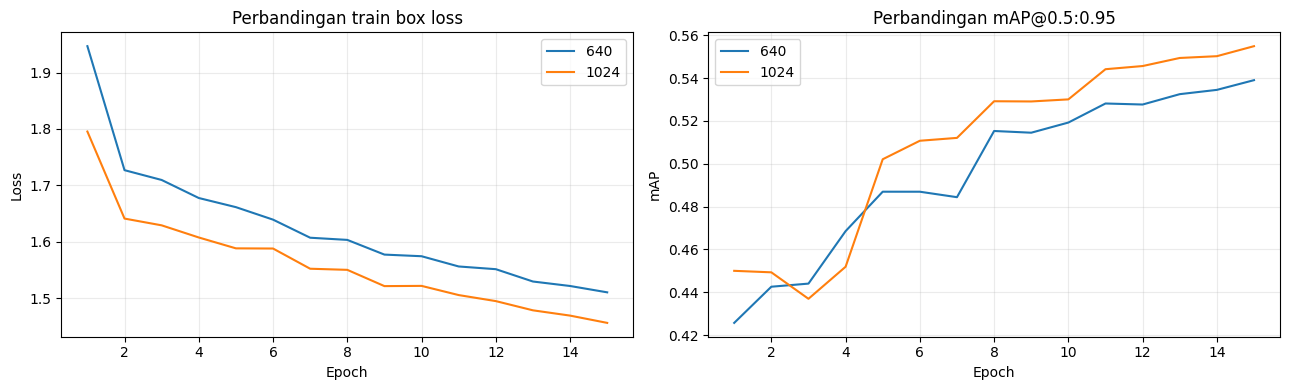

In [27]:
# Membandingkan riwayat pelatihan baseline dan intervensi
highres_csv = os.path.join(highres_dir, "results.csv")

if os.path.exists(baseline_csv) and os.path.exists(highres_csv):
    base_hist = pd.read_csv(baseline_csv)
    high_hist = pd.read_csv(highres_csv)
    base_hist.columns = [c.strip() for c in base_hist.columns]
    high_hist.columns = [c.strip() for c in high_hist.columns]

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))

    # Perbandingan box loss
    if "train/box_loss" in base_hist.columns and "train/box_loss" in high_hist.columns:
        ax[0].plot(base_hist["epoch"], base_hist["train/box_loss"], label="640")
        ax[0].plot(high_hist["epoch"], high_hist["train/box_loss"], label="1024")
    ax[0].set_title("Perbandingan train box loss")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].legend()
    ax[0].grid(alpha=0.25)

    # Perbandingan mAP50-95 pada validation
    metric_col = "metrics/mAP50-95(B)"
    if metric_col in base_hist.columns and metric_col in high_hist.columns:
        ax[1].plot(base_hist["epoch"], base_hist[metric_col], label="640")
        ax[1].plot(high_hist["epoch"], high_hist[metric_col], label="1024")
    ax[1].set_title("Perbandingan mAP@0.5:0.95")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("mAP")
    ax[1].legend()
    ax[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig(os.path.join(REPORT_DIR, "perbandingan_training_640_vs_1024.png"), bbox_inches="tight")
    plt.show()


## 10. Evaluasi keseluruhan dengan metrik Ultralytics

Sel evaluasi lama pada notebook awal menggunakan `YOLO("/content/yolov8n.pt")` di dalam fungsi sehingga argumen `model_path` tidak benar-benar dipakai dan path tersebut juga merupakan gaya Colab. Kode asli **tidak dihapus**; disimpan sebagai komentar pada sel ini. Evaluasi aktif di bawahnya menggunakan checkpoint hasil training pada Kaggle.


In [28]:
# ==============================================================
# KODE EVALUASI AWAL DARI NOTEBOOK (DIPERTAHANKAN SEBAGAI ARSIP)
# Dinonaktifkan agar tidak memakai path /content dan bobot pralatih
# ketika yang seharusnya dievaluasi adalah checkpoint hasil training.
# ==============================================================
# from ultralytics import YOLO
# from ultralytics.utils.benchmarks import ProfileModels
#
#
# def evaluate_coco_metrics(model_path, imgsz):
#     model = YOLO("/content/yolov8n.pt")
#     # Jalankan validasi dengan format penyimpan COCO JSON untuk ekstrak metrik s/m/l
#     metrics = model.val(
#         data="wheat.yaml", imgsz=imgsz, save_json=True, split="val"
#     )
#     return metrics
#
#
# # Evaluasi kedua model
# metrics_base = evaluate_coco_metrics("wheat_exp/baseline_640/weights/best.pt", 640)
# metrics_high = evaluate_coco_metrics("wheat_exp/intervention_1024/weights/best.pt", 1024)
#
# # Cetak Ringkasan mAP Overall & Per Ukuran
# print("=== HASIL EVALUASI METRIK KOMPARATIF ===")
# print(f"Baseline (640x640)   -> mAP50: {metrics_base.box.map50:.3f} | mAP50-95: {metrics_base.box.map:.3f}")
# print(f"Intervensi (1024x1024) -> mAP50: {metrics_high.box.map50:.3f} | mAP50-95: {metrics_high.box.map:.3f}")

# ==============================================================
# EVALUASI YANG DIGUNAKAN UNTUK HASIL AKHIR
# ==============================================================
def evaluate_ultralytics_metrics(model_path, imgsz):
    """Menjalankan validasi Ultralytics pada checkpoint tertentu."""
    model = YOLO(model_path)
    metrics = model.val(
        data="wheat.yaml",
        imgsz=imgsz,
        split="val",
        device=DEVICE,
        conf=0.001,      # threshold rendah agar kurva precision-recall dapat dihitung lengkap
        iou=0.7,         # IoU NMS bawaan yang umum digunakan Ultralytics
        max_det=300,
        plots=True,
        verbose=False,
    )
    return metrics

metrics_base = evaluate_ultralytics_metrics(baseline_best, 640)
metrics_high = evaluate_ultralytics_metrics(highres_best, 1024)

print("=== HASIL EVALUASI ULTRALYTICS ===")
print(f"Baseline 640  -> mAP@0.5: {metrics_base.box.map50:.4f} | mAP@0.5:0.95: {metrics_base.box.map:.4f}")
print(f"High-res 1024 -> mAP@0.5: {metrics_high.box.map50:.4f} | mAP@0.5:0.95: {metrics_high.box.map:.4f}")


Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3115.4±925.8 MB/s, size: 157.0 KB)
val: Scanning /content/dataset/labels/val.cache... 675 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 675/675 202.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 43/43 2.6it/s 16.5s
                   all        675      29695      0.914      0.878      0.938      0.539
Speed: 2.5ms preprocess, 4.6ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to /content/runs/detect/val
Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4395.5±723.4 MB/s, size: 211.6 KB)
val: Scanning /content/dataset

## 11. Evaluasi COCO berdasarkan ukuran objek

Metrik wajib tugas meminta mAP dipecah menjadi **small / medium / large**. Karena output `metrics.box.map` Ultralytics tidak langsung memisahkan AP berdasarkan area, evaluasi berikut membangun ground-truth dan prediksi dalam format COCO lalu menggunakan `pycocotools.COCOeval`.

Nilai yang diambil:
- `AP50` = mAP@0.5
- `AP` = mAP@0.5:0.95
- `AP_small`
- `AP_medium`
- `AP_large`


In [30]:
import json
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

VAL_IMAGES_DIR = os.path.join(OUTPUT_DIR, "images", "val")
VAL_LABELS_DIR = os.path.join(OUTPUT_DIR, "labels", "val")
COCO_DIR = os.path.join(REPORT_DIR, "coco_eval")
os.makedirs(COCO_DIR, exist_ok=True)


def yolo_label_to_xywh(line, W, H):
    """Mengubah label YOLO normalized menjadi bbox COCO [x, y, width, height]."""
    parts = line.strip().split()
    cls_id = int(float(parts[0]))
    xc, yc, bw, bh = map(float, parts[1:5])

    box_w = bw * W
    box_h = bh * H
    x = xc * W - box_w / 2
    y = yc * H - box_h / 2
    return cls_id, [x, y, box_w, box_h]


def build_coco_ground_truth(images_dir, labels_dir, output_json):
    """Membuat JSON ground-truth COCO dari folder image dan label YOLO."""
    images = []
    annotations = []
    categories = [{"id": 1, "name": "wheat"}]
    ann_id = 1

    image_paths = sorted(glob.glob(os.path.join(images_dir, "*.jpg")))
    for image_id, img_path in enumerate(image_paths, start=1):
        file_name = os.path.basename(img_path)
        stem = os.path.splitext(file_name)[0]
        W, H = Image.open(img_path).size

        images.append({
            "id": image_id,
            "file_name": file_name,
            "width": W,
            "height": H,
        })

        label_path = os.path.join(labels_dir, stem + ".txt")
        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f:
                    if not line.strip():
                        continue
                    _, bbox = yolo_label_to_xywh(line, W, H)
                    x, y, bw, bh = bbox
                    annotations.append({
                        "id": ann_id,
                        "image_id": image_id,
                        "category_id": 1,
                        "bbox": [float(x), float(y), float(bw), float(bh)],
                        "area": float(bw * bh),
                        "iscrowd": 0,
                    })
                    ann_id += 1

    coco_dict = {
        "info": {"description": "Global Wheat Detection validation split"},
        "licenses": [],
        "images": images,
        "annotations": annotations,
        "categories": categories,
    }

    with open(output_json, "w") as f:
        json.dump(coco_dict, f)

    return image_paths, {os.path.basename(p): i for i, p in enumerate(image_paths, start=1)}


def make_coco_predictions(model_path, imgsz, images_dir, file_to_id, output_json):
    """Menjalankan YOLO dan menyimpan prediksi ke JSON COCO."""
    model = YOLO(model_path)
    predictions = []

    image_paths = sorted(glob.glob(os.path.join(images_dir, "*.jpg")))
    for img_path in tqdm(image_paths, desc=f"Prediksi imgsz={imgsz}"):
        result = model.predict(
            source=img_path,
            imgsz=imgsz,
            conf=0.001,
            iou=0.7,
            max_det=300,
            device=DEVICE,
            verbose=False,
        )[0]

        image_id = file_to_id[os.path.basename(img_path)]
        if result.boxes is None:
            continue

        boxes = result.boxes.xyxy.cpu().numpy()
        scores = result.boxes.conf.cpu().numpy()

        for box, score in zip(boxes, scores):
            x1, y1, x2, y2 = map(float, box)
            predictions.append({
                "image_id": int(image_id),
                "category_id": 1,
                "bbox": [x1, y1, x2 - x1, y2 - y1],
                "score": float(score),
            })

    with open(output_json, "w") as f:
        json.dump(predictions, f)

    return predictions


def evaluate_coco_by_size(gt_json, pred_json):
    """Mengembalikan AP overall dan AP small/medium/large dari COCOeval."""
    coco_gt = COCO(gt_json)
    coco_dt = coco_gt.loadRes(pred_json)
    evaluator = COCOeval(coco_gt, coco_dt, iouType="bbox")
    evaluator.evaluate()
    evaluator.accumulate()
    evaluator.summarize()

    stats = evaluator.stats
    return {
        "mAP@0.5:0.95": float(stats[0]),
        "mAP@0.5": float(stats[1]),
        "AP_small": float(stats[3]),
        "AP_medium": float(stats[4]),
        "AP_large": float(stats[5]),
    }


# 1) Buat ground-truth COCO satu kali
gt_json = os.path.join(COCO_DIR, "ground_truth_val.json")
val_paths, file_to_id = build_coco_ground_truth(
    VAL_IMAGES_DIR, VAL_LABELS_DIR, gt_json
)

# 2) Prediksi baseline dan intervensi
pred_base_json = os.path.join(COCO_DIR, "pred_baseline_640.json")
pred_high_json = os.path.join(COCO_DIR, "pred_highres_1024.json")

_ = make_coco_predictions(
    baseline_best, 640, VAL_IMAGES_DIR, file_to_id, pred_base_json
)
_ = make_coco_predictions(
    highres_best, 1024, VAL_IMAGES_DIR, file_to_id, pred_high_json
)

# 3) Evaluasi mAP dan AP berdasarkan ukuran objek
coco_base = evaluate_coco_by_size(gt_json, pred_base_json)
coco_high = evaluate_coco_by_size(gt_json, pred_high_json)

print("Baseline 640:", coco_base)
print("High-res 1024:", coco_high)


Prediksi imgsz=640:   0%|          | 0/675 [00:00<?, ?it/s]

Prediksi imgsz=1024:   0%|          | 0/675 [00:00<?, ?it/s]

loading annotations into memory...
Done (t=0.14s)
creating index...
index created!
Loading and preparing results...
DONE (t=2.20s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=48.29s).
Accumulating evaluation results...
DONE (t=0.60s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.529
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.922
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.541
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.133
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.523
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.577
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.017
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.154
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

## 12. Tabel dan grafik perbandingan utama

Seluruh angka pada tabel dan grafik berikut berasal langsung dari output eksperimen sehingga dapat digunakan pada laporan tanpa mengetik angka secara manual.


,Eksperimen,mAP@0.5:0.95,mAP@0.5,AP_small,AP_medium,AP_large
0,YOLOv8n 640 (Baseline),0.5295,0.9218,0.1330,0.5228,0.5767
1,YOLOv8n 1024 (Intervensi),0.5429,0.9306,0.1461,0.5376,0.5814
2,Delta (1024 - 640),0.0134,0.0088,0.0131,0.0149,0.0046


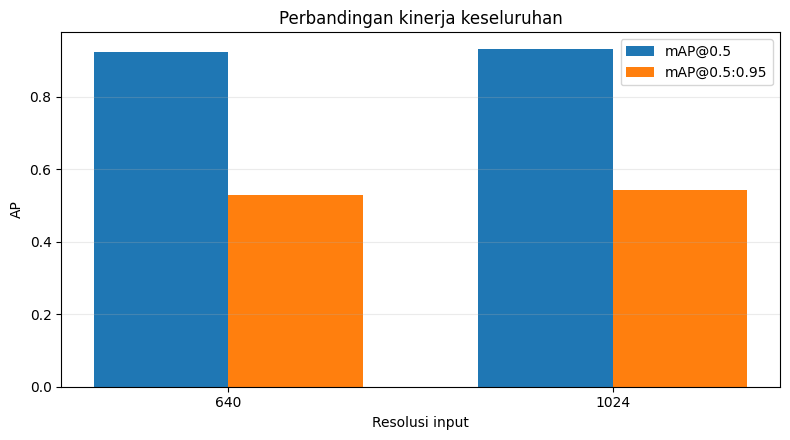

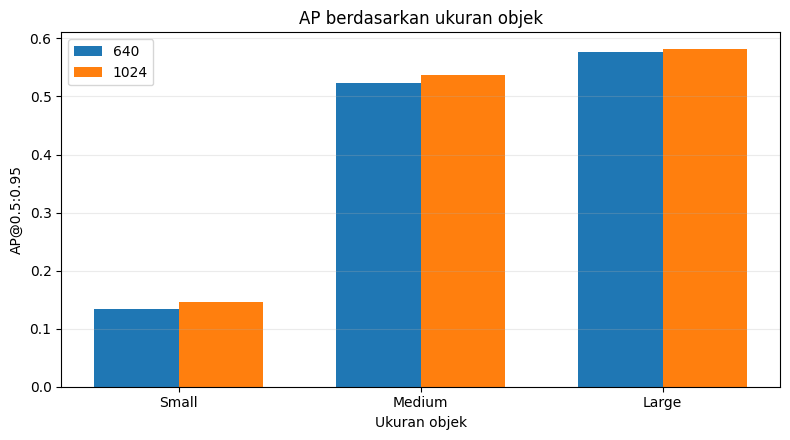

In [31]:
# Menggabungkan hasil evaluasi menjadi satu tabel utama
comparison = pd.DataFrame([
    {
        "Eksperimen": "YOLOv8n 640 (Baseline)",
        **coco_base,
    },
    {
        "Eksperimen": "YOLOv8n 1024 (Intervensi)",
        **coco_high,
    },
])

# Menambahkan delta agar pengaruh intervensi langsung terlihat
metric_cols = ["mAP@0.5", "mAP@0.5:0.95", "AP_small", "AP_medium", "AP_large"]
delta = {"Eksperimen": "Delta (1024 - 640)"}
for col in metric_cols:
    delta[col] = comparison.loc[1, col] - comparison.loc[0, col]
comparison_with_delta = pd.concat([comparison, pd.DataFrame([delta])], ignore_index=True)

display(comparison_with_delta.round(4))
comparison_with_delta.to_csv(
    os.path.join(REPORT_DIR, "tabel_perbandingan_metrik.csv"), index=False
)

# Grafik mAP overall
x = np.arange(2)
width = 0.35
plt.figure(figsize=(8, 4.5))
plt.bar(x - width / 2, comparison["mAP@0.5"], width, label="mAP@0.5")
plt.bar(x + width / 2, comparison["mAP@0.5:0.95"], width, label="mAP@0.5:0.95")
plt.xticks(x, ["640", "1024"])
plt.xlabel("Resolusi input")
plt.ylabel("AP")
plt.title("Perbandingan kinerja keseluruhan")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "map_overall_640_vs_1024.png"), bbox_inches="tight")
plt.show()

# Grafik AP berdasarkan ukuran objek
size_cols = ["AP_small", "AP_medium", "AP_large"]
x = np.arange(len(size_cols))
plt.figure(figsize=(8, 4.5))
plt.bar(x - width / 2, comparison.loc[0, size_cols], width, label="640")
plt.bar(x + width / 2, comparison.loc[1, size_cols], width, label="1024")
plt.xticks(x, ["Small", "Medium", "Large"])
plt.xlabel("Ukuran objek")
plt.ylabel("AP@0.5:0.95")
plt.title("AP berdasarkan ukuran objek")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "ap_by_object_size.png"), bbox_inches="tight")
plt.show()


## 13. Pengukuran waktu inferensi

Resolusi lebih tinggi dapat meningkatkan akurasi tetapi juga meningkatkan biaya komputasi. Karena itu waktu inferensi per citra diukur sebagai informasi trade-off tambahan.


In [32]:
# Mengukur kecepatan inferensi pada subset validation yang sama
import time


def ukur_inference_ms(model_path, imgsz, image_paths, n_images=50):
    model = YOLO(model_path)
    subset = image_paths[: min(n_images, len(image_paths))]
    elapsed = []

    # Warm-up agar pengukuran pertama tidak terlalu bias oleh inisialisasi
    if subset:
        _ = model.predict(subset[0], imgsz=imgsz, conf=0.25, device=DEVICE, verbose=False)
        if torch.cuda.is_available():
            torch.cuda.synchronize()

    for img_path in subset:
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        _ = model.predict(img_path, imgsz=imgsz, conf=0.25, device=DEVICE, verbose=False)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        elapsed.append((time.perf_counter() - t0) * 1000)

    return float(np.mean(elapsed))

ms_640 = ukur_inference_ms(baseline_best, 640, val_paths)
ms_1024 = ukur_inference_ms(highres_best, 1024, val_paths)

speed_table = pd.DataFrame({
    "Eksperimen": ["YOLOv8n 640", "YOLOv8n 1024"],
    "ms/citra": [ms_640, ms_1024],
})

display(speed_table.round(2))
speed_table.to_csv(os.path.join(REPORT_DIR, "waktu_inferensi.csv"), index=False)


,Eksperimen,ms/citra
0,YOLOv8n 640,17.12
1,YOLOv8n 1024,20.16


## 14. Analisis *failure cases*: objek padat dan kecil

Untuk analisis kritis, dipilih beberapa citra validation dengan jumlah objek kecil terbanyak. Setiap citra ditampilkan dalam tiga versi:

1. Ground truth
2. Prediksi baseline 640
3. Prediksi intervensi 1024

Visual ini dapat dimasukkan langsung ke bagian *failure case analysis* pada laporan.


,path,small_count,total_count
87,dataset/images/val/19f4faf0f.jpg,5,71
575,dataset/images/val/db0fdecd3.jpg,4,70
393,dataset/images/val/93f9b571e.jpg,4,68
657,dataset/images/val/fabd1d799.jpg,4,57
493,dataset/images/val/b74131d1f.jpg,3,88
444,dataset/images/val/a7e2015b3.jpg,3,85
182,dataset/images/val/3f23c607b.jpg,3,81
401,dataset/images/val/96b872ec8.jpg,3,80
633,dataset/images/val/f14055096.jpg,3,80
55,dataset/images/val/132a92818.jpg,3,75


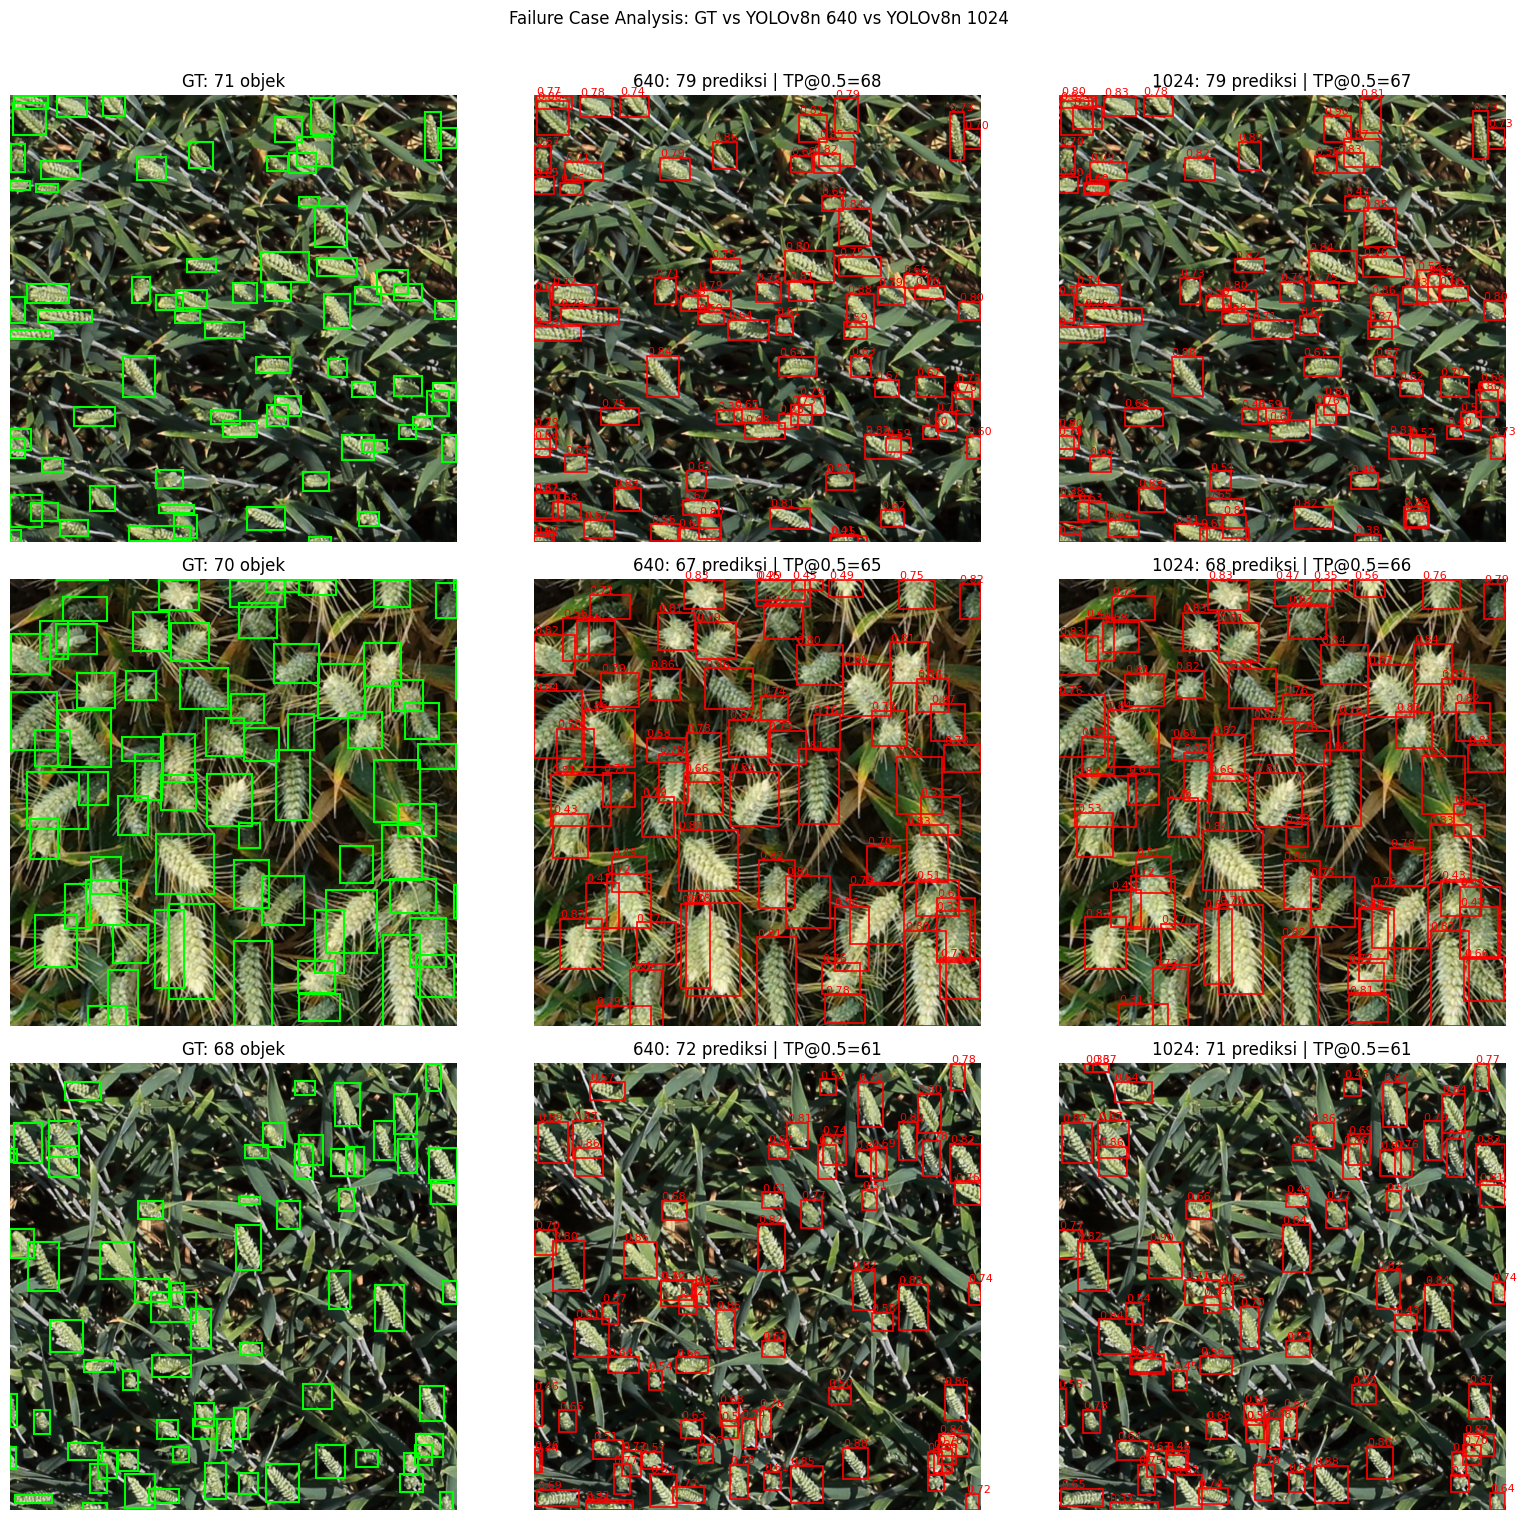

,image_id,GT,Deteksi_640,TP_640_IoU50,Deteksi_1024,TP_1024_IoU50
0,19f4faf0f,71,79,68,79,67
1,db0fdecd3,70,67,65,68,66
2,93f9b571e,68,72,61,71,61


In [33]:
# Fungsi membaca ground-truth YOLO menjadi koordinat xyxy piksel
def load_gt_xyxy(image_path, label_path):
    W, H = Image.open(image_path).size
    boxes = []
    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f:
                if not line.strip():
                    continue
                _, xywh = yolo_label_to_xywh(line, W, H)
                x, y, bw, bh = xywh
                boxes.append([x, y, x + bw, y + bh])
    return np.asarray(boxes, dtype=float).reshape(-1, 4)


def box_iou_matrix(a, b):
    """Menghitung matriks IoU antara dua kumpulan bbox format xyxy."""
    a = np.asarray(a, dtype=float).reshape(-1, 4)
    b = np.asarray(b, dtype=float).reshape(-1, 4)
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)), dtype=float)

    ix1 = np.maximum(a[:, None, 0], b[None, :, 0])
    iy1 = np.maximum(a[:, None, 1], b[None, :, 1])
    ix2 = np.minimum(a[:, None, 2], b[None, :, 2])
    iy2 = np.minimum(a[:, None, 3], b[None, :, 3])

    inter = np.maximum(ix2 - ix1, 0) * np.maximum(iy2 - iy1, 0)
    area_a = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1])
    area_b = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    union = area_a[:, None] + area_b[None, :] - inter
    return inter / np.maximum(union, 1e-9)


def greedy_match_count(pred_boxes, pred_scores, gt_boxes, iou_thr=0.5):
    """Menghitung jumlah ground-truth yang cocok dengan prediksi pada IoU tertentu."""
    if len(pred_boxes) == 0 or len(gt_boxes) == 0:
        return 0

    order = np.argsort(-np.asarray(pred_scores))
    used_gt = np.zeros(len(gt_boxes), dtype=bool)
    tp = 0

    for idx in order:
        ious = box_iou_matrix([pred_boxes[idx]], gt_boxes)[0]
        j = int(np.argmax(ious))
        if ious[j] >= iou_thr and not used_gt[j]:
            used_gt[j] = True
            tp += 1
    return tp


# Memilih citra dengan objek small terbanyak; total objek dipakai sebagai tie-breaker
candidate_rows = []
for img_path in val_paths:
    stem = os.path.splitext(os.path.basename(img_path))[0]
    label_path = os.path.join(VAL_LABELS_DIR, stem + ".txt")
    gt = load_gt_xyxy(img_path, label_path)
    areas = (gt[:, 2] - gt[:, 0]) * (gt[:, 3] - gt[:, 1]) if len(gt) else np.array([])
    candidate_rows.append({
        "path": img_path,
        "small_count": int(np.sum(areas < 32 ** 2)),
        "total_count": int(len(gt)),
    })

candidate_df = pd.DataFrame(candidate_rows).sort_values(
    ["small_count", "total_count"], ascending=False
)
failure_paths = candidate_df.head(3)["path"].tolist()

display(candidate_df.head(10))

model_base_eval = YOLO(baseline_best)
model_high_eval = YOLO(highres_best)

fig, axs = plt.subplots(len(failure_paths), 3, figsize=(16, 5 * len(failure_paths)))
if len(failure_paths) == 1:
    axs = np.array([axs])

failure_summary = []
for row_idx, img_path in enumerate(failure_paths):
    stem = os.path.splitext(os.path.basename(img_path))[0]
    label_path = os.path.join(VAL_LABELS_DIR, stem + ".txt")
    gt = load_gt_xyxy(img_path, label_path)

    pred_base = model_base_eval.predict(
        img_path, imgsz=640, conf=0.25, iou=0.7, max_det=300,
        device=DEVICE, verbose=False
    )[0]
    pred_high = model_high_eval.predict(
        img_path, imgsz=1024, conf=0.25, iou=0.7, max_det=300,
        device=DEVICE, verbose=False
    )[0]

    base_boxes = pred_base.boxes.xyxy.cpu().numpy() if pred_base.boxes is not None else np.empty((0, 4))
    base_scores = pred_base.boxes.conf.cpu().numpy() if pred_base.boxes is not None else np.empty((0,))
    high_boxes = pred_high.boxes.xyxy.cpu().numpy() if pred_high.boxes is not None else np.empty((0, 4))
    high_scores = pred_high.boxes.conf.cpu().numpy() if pred_high.boxes is not None else np.empty((0,))

    tp_base = greedy_match_count(base_boxes, base_scores, gt, iou_thr=0.5)
    tp_high = greedy_match_count(high_boxes, high_scores, gt, iou_thr=0.5)

    failure_summary.append({
        "image_id": stem,
        "GT": len(gt),
        "Deteksi_640": len(base_boxes),
        "TP_640_IoU50": tp_base,
        "Deteksi_1024": len(high_boxes),
        "TP_1024_IoU50": tp_high,
    })

    # Kolom 1: Ground truth
    axs[row_idx, 0].imshow(Image.open(img_path))
    draw_boxes(axs[row_idx, 0], gt, "lime", lw=1.5)
    axs[row_idx, 0].set_title(f"GT: {len(gt)} objek")
    axs[row_idx, 0].axis("off")

    # Kolom 2: Baseline 640
    axs[row_idx, 1].imshow(Image.open(img_path))
    draw_boxes(axs[row_idx, 1], base_boxes, "red", lw=1.2, scores=base_scores)
    axs[row_idx, 1].set_title(f"640: {len(base_boxes)} prediksi | TP@0.5={tp_base}")
    axs[row_idx, 1].axis("off")

    # Kolom 3: Intervensi 1024
    axs[row_idx, 2].imshow(Image.open(img_path))
    draw_boxes(axs[row_idx, 2], high_boxes, "red", lw=1.2, scores=high_scores)
    axs[row_idx, 2].set_title(f"1024: {len(high_boxes)} prediksi | TP@0.5={tp_high}")
    axs[row_idx, 2].axis("off")

plt.suptitle("Failure Case Analysis: GT vs YOLOv8n 640 vs YOLOv8n 1024", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "failure_cases_640_vs_1024.png"), bbox_inches="tight")
plt.show()

failure_summary_df = pd.DataFrame(failure_summary)
display(failure_summary_df)
failure_summary_df.to_csv(
    os.path.join(REPORT_DIR, "failure_case_summary.csv"), index=False
)


## 15. Analisis tambahan ambang confidence dan NMS (opsional)

Bagian ini menyerupai eksperimen pada notebook tutorial. Secara default dimatikan agar `Run All` tidak menambah waktu terlalu banyak. Ubah `RUN_THRESHOLD_SWEEP = True` jika ingin menganalisis sensitivitas model terhadap nilai confidence dan IoU NMS.


In [34]:
RUN_THRESHOLD_SWEEP = False

if RUN_THRESHOLD_SWEEP:
    threshold_rows = []
    model_sweep = YOLO(highres_best)
    subset_paths = val_paths[:25]

    for nms_iou in [0.5, 0.7, 0.9]:
        for conf_thr in [0.10, 0.25, 0.50, 0.75]:
            total_pred = 0
            total_tp = 0
            total_gt = 0

            for img_path in subset_paths:
                stem = os.path.splitext(os.path.basename(img_path))[0]
                gt = load_gt_xyxy(
                    img_path,
                    os.path.join(VAL_LABELS_DIR, stem + ".txt"),
                )
                result = model_sweep.predict(
                    img_path,
                    imgsz=1024,
                    conf=conf_thr,
                    iou=nms_iou,
                    max_det=300,
                    device=DEVICE,
                    verbose=False,
                )[0]

                pred_boxes = result.boxes.xyxy.cpu().numpy() if result.boxes is not None else np.empty((0, 4))
                pred_scores = result.boxes.conf.cpu().numpy() if result.boxes is not None else np.empty((0,))

                total_pred += len(pred_boxes)
                total_gt += len(gt)
                total_tp += greedy_match_count(pred_boxes, pred_scores, gt, iou_thr=0.5)

            precision = total_tp / max(total_pred, 1)
            recall = total_tp / max(total_gt, 1)
            f1 = 2 * precision * recall / max(precision + recall, 1e-9)

            threshold_rows.append({
                "NMS IoU": nms_iou,
                "Confidence": conf_thr,
                "Precision": precision,
                "Recall": recall,
                "F1": f1,
            })

    threshold_df = pd.DataFrame(threshold_rows)
    display(threshold_df.round(4))
    display(threshold_df.pivot(index="Confidence", columns="NMS IoU", values="F1").round(4))
else:
    print("Threshold sweep dilewati. Ubah RUN_THRESHOLD_SWEEP=True jika ingin menjalankannya.")


Threshold sweep dilewati. Ubah RUN_THRESHOLD_SWEEP=True jika ingin menjalankannya.


## 16. Ringkasan otomatis hasil eksperimen

Sel ini tidak menggantikan analisis pada laporan, tetapi membantu membaca arah hasil secara objektif berdasarkan angka yang benar-benar diperoleh notebook.


In [36]:
# Membuat ringkasan perubahan metrik akibat intervensi resolusi tinggi
delta_map50 = coco_high["mAP@0.5"] - coco_base["mAP@0.5"]
delta_map = coco_high["mAP@0.5:0.95"] - coco_base["mAP@0.5:0.95"]
delta_small = coco_high["AP_small"] - coco_base["AP_small"]
delta_medium = coco_high["AP_medium"] - coco_base["AP_medium"]
delta_large = coco_high["AP_large"] - coco_base["AP_large"]

print("=== RINGKASAN PERUBAHAN 1024 TERHADAP 640 ===")
print(f"Δ mAP@0.5       : {delta_map50:+.4f}")
print(f"Δ mAP@0.5:0.95  : {delta_map:+.4f}")
print(f"Δ AP small      : {delta_small:+.4f}")
print(f"Δ AP medium     : {delta_medium:+.4f}")
print(f"Δ AP large      : {delta_large:+.4f}")
print(f"Δ waktu inferensi: {ms_1024 - ms_640:+.2f} ms/citra")

if delta_small > 0:
    print("Interpretasi awal: resolusi 1024 meningkatkan AP pada objek small.")
elif delta_small < 0:
    print("Interpretasi awal: resolusi 1024 tidak meningkatkan AP pada objek small pada eksperimen ini.")
else:
    print("Interpretasi awal: AP objek small tidak berubah.")

if delta_map > 0:
    print("mAP keseluruhan juga meningkat pada resolusi 1024.")
else:
    print("mAP keseluruhan tidak meningkat pada resolusi 1024; analisis failure case diperlukan untuk menjelaskan penyebabnya.")


=== RINGKASAN PERUBAHAN 1024 TERHADAP 640 ===
Δ mAP@0.5       : +0.0088
Δ mAP@0.5:0.95  : +0.0134
Δ AP small      : +0.0131
Δ AP medium     : +0.0149
Δ AP large      : +0.0046
Δ waktu inferensi: +3.04 ms/citra
Interpretasi awal: resolusi 1024 meningkatkan AP pada objek small.
mAP keseluruhan juga meningkat pada resolusi 1024.


## 17. Simpan model dan artefak hasil

Sel penyimpanan model dari notebook awal tetap dipertahankan. Setelah itu ditambahkan penyimpanan checkpoint terbaik dan file hasil yang dibutuhkan untuk laporan.


In [37]:
model_baseline.save("/kaggle/working/my_custom_yolo.pt")

In [39]:
# Menyalin checkpoint terbaik ke lokasi yang mudah diunduh dari Kaggle Output
final_baseline_path = "/kaggle/working/yolov8n_wheat_baseline_640_best.pt"
final_highres_path = "/kaggle/working/yolov8n_wheat_highres_1024_best.pt"

shutil.copy2(baseline_best, final_baseline_path)
shutil.copy2(highres_best, final_highres_path)

# Simpan ringkasan konfigurasi eksperimen
experiment_config = pd.DataFrame([
    {
        "experiment": "baseline_640",
        "model": "yolov8n.pt",
        "imgsz": 640,
        "epochs": 15,
        "batch": 16,
        "seed": SEED,
        "checkpoint": final_baseline_path,
    },
    {
        "experiment": "intervention_1024",
        "model": "yolov8n.pt",
        "imgsz": 1024,
        "epochs": 15,
        "batch": 16,
        "seed": SEED,
        "checkpoint": final_highres_path,
    },
])
experiment_config.to_csv(
    os.path.join(REPORT_DIR, "experiment_config.csv"), index=False
)

display(experiment_config)
print("Model baseline tersimpan di:", final_baseline_path)
print("Model high-res tersimpan di:", final_highres_path)
print("Semua tabel/gambar laporan tersimpan di:", REPORT_DIR)


,experiment,model,imgsz,epochs,batch,seed,checkpoint
0,baseline_640,yolov8n.pt,640,15,16,42,/kaggle/working/yolov8n_wheat_baseline_640_bes...
1,intervention_1024,yolov8n.pt,1024,15,16,42,/kaggle/working/yolov8n_wheat_highres_1024_bes...


Model baseline tersimpan di: /kaggle/working/yolov8n_wheat_baseline_640_best.pt
Model high-res tersimpan di: /kaggle/working/yolov8n_wheat_highres_1024_best.pt
Semua tabel/gambar laporan tersimpan di: /content/Report
